In [1]:
import os
import skrf as rf
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

In [2]:
def smooth_network(network, window=11, poly=3):
    """
    Smooth all S-parameters of a Network using Savitzky–Golay filter.
    Returns a new smoothed Network.
    """
    s = network.s.copy()
    n_freq, n_port, _ = s.shape

    s_smooth = np.zeros_like(s, dtype=complex)

    for i in range(n_port):
        for j in range(n_port):
            real_part = np.real(s[:, i, j])
            imag_part = np.imag(s[:, i, j])

            real_smooth = savgol_filter(real_part, window, poly)
            imag_smooth = savgol_filter(imag_part, window, poly)

            s_smooth[:, i, j] = real_smooth + 1j * imag_smooth

    smoothed_network = rf.Network(
        frequency=network.frequency,
        s=s_smooth,
        z0=network.z0
    )

    return smoothed_network


def load_directory(directory_path, window=30, poly=3):
    """
    Reads all .s2p files in a directory.
    Can Return two lists:
        {directory_name}_original
        {directory_name}_smoothed
    """

    directory_name = os.path.basename(os.path.normpath(directory_path))

    original_list = []
    smoothed_list = []

    for file in sorted(os.listdir(directory_path)):
        if file.lower().endswith(".s2p"):

            full_path = os.path.join(directory_path, file)

            # Load original network
            ntwk = rf.Network(full_path)

            # Use filename (without extension) as network name
            name = os.path.splitext(file)[0]
            ntwk.name = name

            original_list.append(ntwk)

            # Create smoothed version
            ntwk_smooth = smooth_network(ntwk, window, poly)
            ntwk_smooth.name = name

            smoothed_list.append(ntwk_smooth)

    # Dynamically create variable names
    globals()[f"{directory_name}_measured"] = original_list
    globals()[f"{directory_name}_smoothed"] = smoothed_list

    return original_list, smoothed_list


def avg_return_loss(ntwk):
    s11_db = ntwk.s_db[:,0,0]
    return np.mean(s11_db)
def worst_return_loss(ntwk):
    return np.max(ntwk.s_db[:640,0,0])   # closest to 0 dB
def avg_transmit_loss(ntwk):
    s11_db = ntwk.s_db[:,1,0]
    return np.mean(s11_db)
def worst_transmit_loss(ntwk):
    return np.max(ntwk.s_db[:,1,0])   # closest to 0 dB

def db_to_pct(x):
    return 100 * 10**(x / 10)

def pct_to_db(y):
    return 10 * np.log10(y / 100)

In [3]:
g_width1, g_width1_smoothened = load_directory('g_widths',window=100, poly=3)
g_width1_smoothened

[2-Port Network: '1g',  1000000000.0-45000000000.0 Hz, 1601 pts, z0=[50.+0.j 50.+0.j],
 2-Port Network: '2g',  1000000000.0-45000000000.0 Hz, 1601 pts, z0=[50.+0.j 50.+0.j],
 2-Port Network: '3g',  1000000000.0-45000000000.0 Hz, 1601 pts, z0=[50.+0.j 50.+0.j],
 2-Port Network: '4g',  1000000000.0-45000000000.0 Hz, 1601 pts, z0=[50.+0.j 50.+0.j],
 2-Port Network: '5g',  1000000000.0-45000000000.0 Hz, 1601 pts, z0=[50.+0.j 50.+0.j]]

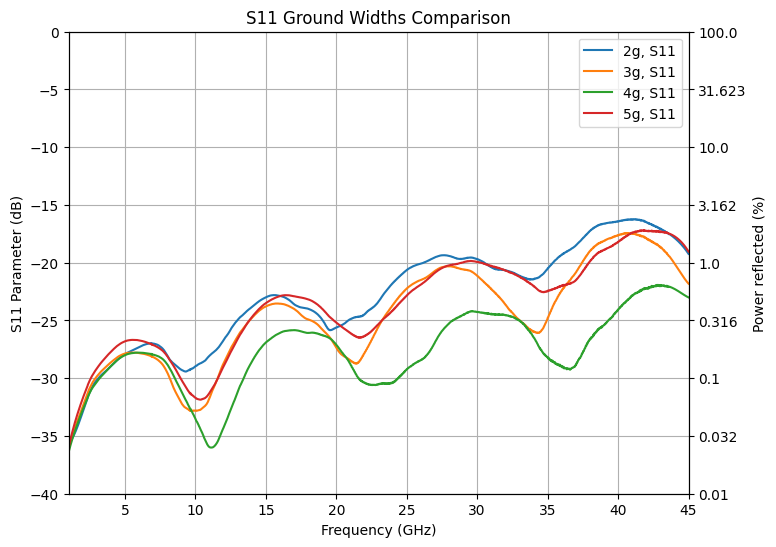

In [4]:
import matplotlib.patches as mpatches
plt.figure(figsize=(8, 6))
ax1 = plt.gca()

for ntwk in g_width1_smoothened[1:]:
    ntwk.frequency.unit = 'GHz'
    ntwk.plot_s_db(m=0,n=0)
plt.grid(True)
plt.xlabel('Frequency (GHz)')
plt.ylabel('S11 Parameter (dB)')
plt.title('S11 Ground Widths Comparison')

# --- SET Y-AXIS LIMITS HERE ---
ax1.set_ylim(-40, 0)


# --- SECONDARY AXIS CODE ---
ax2 = ax1.twinx()

# Sync limits with ax1
ax2.set_ylim(ax1.get_ylim())

# Sync ticks with ax1 and convert labels to percentage
y_ticks_db = ax1.get_yticks()
y_ticks_pct = [round(10**(tick/10) * 100, 3) for tick in y_ticks_db]

ax2.set_yticks(y_ticks_db)
ax2.set_yticklabels(y_ticks_pct)
ax2.set_ylabel('Power reflected (%)')

# Save and show
plt.savefig('S11_Ground_Widths_Comparison.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\hrith\AppData\Local\Temp\ipykernel_14404\500347415.py:85: RuntimeWarning: divide by zero encountered in log10
  return 10 * np.log10(y / 100)


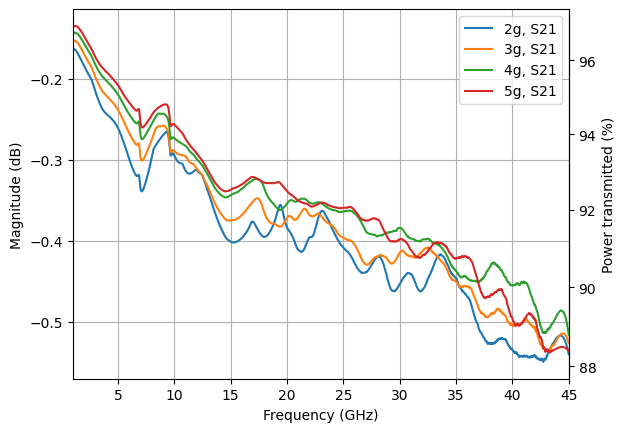

<Figure size 640x480 with 0 Axes>

In [5]:
for ntwk in g_width1_smoothened[1:]:
    ntwk.frequency.unit = 'GHz'
    ntwk.plot_s_db(m=1,n=0)
plt.grid(True)
ax1 = plt.gca()
ax2 = ax1.secondary_yaxis('right', functions=(db_to_pct, pct_to_db))
ax2.set_ylabel('Power transmitted (%)')
ax2.set_ylim(db_to_pct(ax1.get_ylim()[0]), db_to_pct(ax1.get_ylim()[1]))
plt.show()

plt.savefig('S21_Ground_Widths_Comparison.png', dpi=300)

In [6]:
slotwidth, slotwidth_smoothened = load_directory('slot_widths',window=100, poly=2)

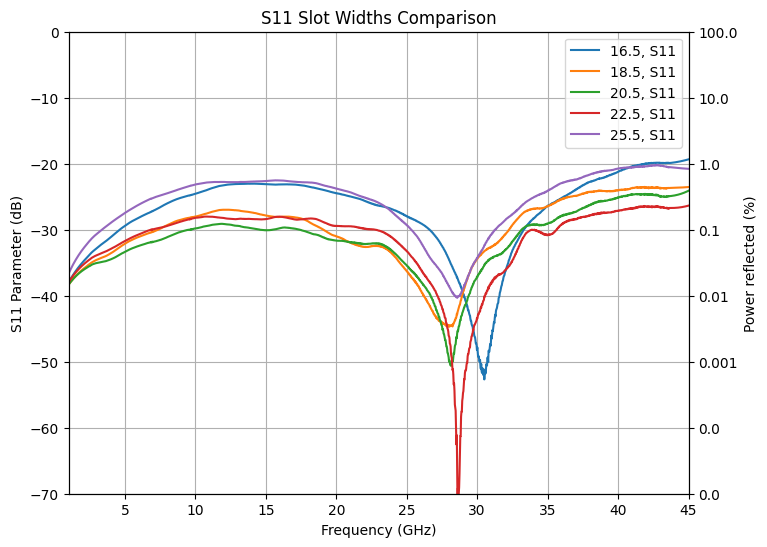

In [7]:
import matplotlib.patches as mpatches
plt.figure(figsize=(8, 6))
ax1 = plt.gca()

for ntwk in slotwidth_smoothened:
    ntwk.frequency.unit = 'GHz'
    ntwk.plot_s_db(m=0,n=0)
plt.grid(True)
plt.xlabel('Frequency (GHz)')
plt.ylabel('S11 Parameter (dB)')
plt.title('S11 Slot Widths Comparison')

# --- SET Y-AXIS LIMITS HERE ---
ax1.set_ylim(-70, 0)


# --- SECONDARY AXIS CODE ---
ax2 = ax1.twinx()

# Sync limits with ax1
ax2.set_ylim(ax1.get_ylim())

# Sync ticks with ax1 and convert labels to percentage
y_ticks_db = ax1.get_yticks()
y_ticks_pct = [round(10**(tick/10) * 100, 3) for tick in y_ticks_db]

ax2.set_yticks(y_ticks_db)
ax2.set_yticklabels(y_ticks_pct)
ax2.set_ylabel('Power reflected (%)')

# Save and show
plt.savefig('S11_Slot_Widths_Comparison.png', dpi=300, bbox_inches='tight')
plt.show()

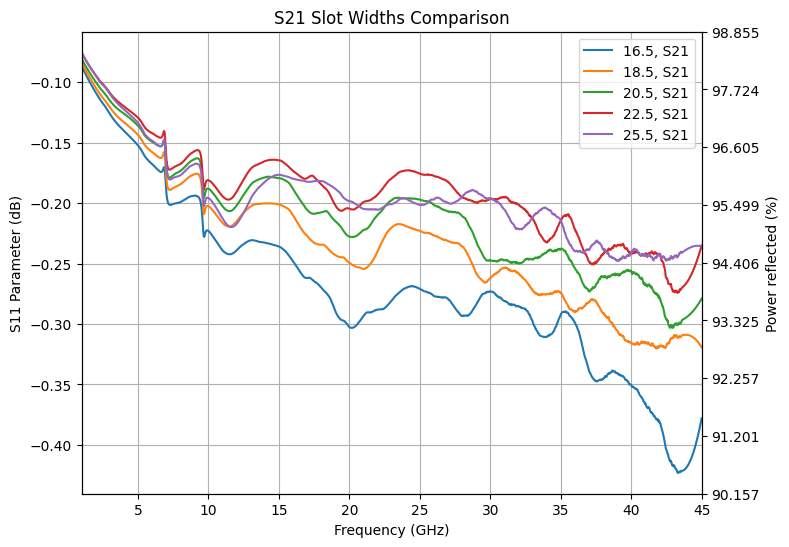

In [8]:
import matplotlib.patches as mpatches
plt.figure(figsize=(8, 6))
ax1 = plt.gca()

for ntwk in slotwidth_smoothened:
    ntwk.frequency.unit = 'GHz'
    ntwk.plot_s_db(m=1,n=0)
plt.grid(True)
plt.xlabel('Frequency (GHz)')
plt.ylabel('S11 Parameter (dB)')
plt.title('S21 Slot Widths Comparison')

# --- SET Y-AXIS LIMITS HERE ---
# ax1.set_ylim(-70, 0)


# --- SECONDARY AXIS CODE ---
ax2 = ax1.twinx()

# Sync limits with ax1
ax2.set_ylim(ax1.get_ylim())

# Sync ticks with ax1 and convert labels to percentage
y_ticks_db = ax1.get_yticks()
y_ticks_pct = [round(10**(tick/10) * 100, 3) for tick in y_ticks_db]

ax2.set_yticks(y_ticks_db)
ax2.set_yticklabels(y_ticks_pct)
ax2.set_ylabel('Power reflected (%)')

# Save and show
plt.savefig('S21_Slot_Widths_Comparison.png', dpi=300, bbox_inches='tight')
plt.show()

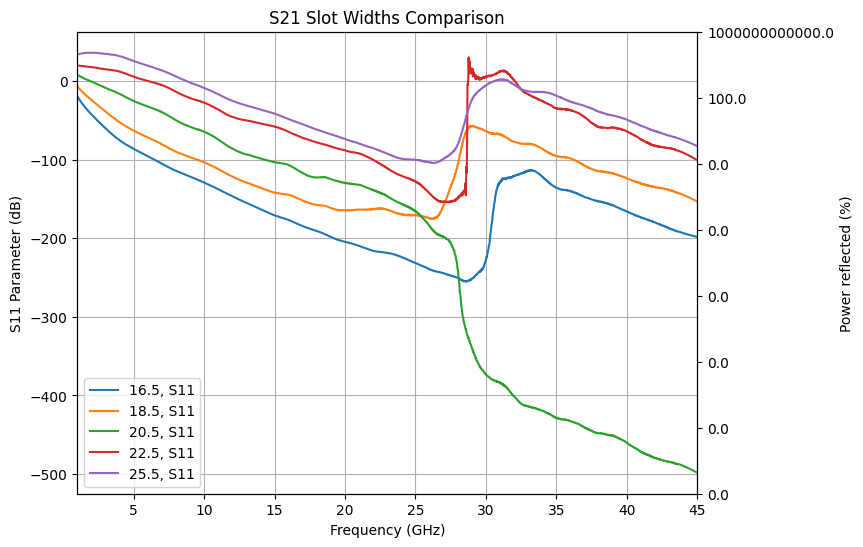

In [9]:
import matplotlib.patches as mpatches
plt.figure(figsize=(8, 6))
ax1 = plt.gca()

for ntwk in slotwidth_smoothened:
    ntwk.frequency.unit = 'GHz'
    ntwk.plot_s_deg_unwrap(0, 0)
plt.grid(True)
plt.xlabel('Frequency (GHz)')
plt.ylabel('S11 Parameter (dB)')
plt.title('S21 Slot Widths Comparison')

# --- SET Y-AXIS LIMITS HERE ---
# ax1.set_ylim(-70, 0)


# --- SECONDARY AXIS CODE ---
ax2 = ax1.twinx()

# Sync limits with ax1
ax2.set_ylim(ax1.get_ylim())

# Sync ticks with ax1 and convert labels to percentage
y_ticks_db = ax1.get_yticks()
y_ticks_pct = [round(10**(tick/10) * 100, 3) for tick in y_ticks_db]

ax2.set_yticks(y_ticks_db)
ax2.set_yticklabels(y_ticks_pct)
ax2.set_ylabel('Power reflected (%)')

# Save and show
plt.savefig('S21_Slot_Widths_Comparison.png', dpi=300, bbox_inches='tight')
plt.show()